# **Análisis de contenido de Netflix**

El objetivo de este proyecto es analizar las características de las películas disponibles en Netflix, enfocándonos en variables como duración, año de lanzamiento y clasificación (rating).

Desde una perspectiva de negocio, este análisis permite entender patrones en la producción de contenido, como la duración típica de las películas y su distribución en el tiempo.

Para este estudio se utilizó una muestra de 500 registros del dataset original.

Es importante mencionar que el análisis se enfoca únicamente en películas, ya que las series presentan una estructura diferente (temporadas) que no es directamente comparable en términos de duración.

**Preguntas de análisis**
1.   ¿Cuál es la duración promedio de las películas en Netflix?
2.   ¿Existe relación entre la duración y el año de lanzamiento?
3.   ¿La clasificación (rating) influye en la duración de las películas?

**Hipótesis**
*   La duración de las películas se mantiene dentro de un rango relativamente estable.
*   No existe una relación fuerte entre el año de lanzamiento y la duración.
*   La clasificación no influye significativamente en la duración.





In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("https://raw.githubusercontent.com/dark-yamoi/ProyectoNetflix/refs/heads/main/netflix_titles.csv")

In [19]:
df = df.sample(500, random_state=42)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utka...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underach...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall di..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemm...",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive anim...
1688,s1689,TV Show,We Are the Champions,NaN,NaN,United States,"November 17, 2020",2020,TV-MA,1 Season,"Docuseries, Reality TV","Explore an array of unique competitions, from ..."
1349,s1350,TV Show,"Pablo Escobar, el patrón del mal",NaN,"Andrés Parra, Angie Cepeda, Cecilia Navia, Vic...",Colombia,"February 3, 2021",2012,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",From his days as a petty thief to becoming hea...


In [20]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 4970 to 1665
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       500 non-null    object
 1   type          500 non-null    object
 2   title         500 non-null    object
 3   director      336 non-null    object
 4   cast          459 non-null    object
 5   country       454 non-null    object
 6   date_added    500 non-null    object
 7   release_year  500 non-null    int64 
 8   rating        500 non-null    object
 9   duration      500 non-null    object
 10  listed_in     500 non-null    object
 11  description   500 non-null    object
dtypes: int64(1), object(11)
memory usage: 50.8+ KB


,0
show_id,0
type,0
title,0
director,164
cast,41
country,46
date_added,0
release_year,0
rating,0
duration,0


**Limpieza de datos**

Se transformó la variable "duration", que originalmente estaba en formato texto (por ejemplo, "90 min"), a un formato numérico para facilitar su análisis.

Además, se eliminaron los registros con valores nulos en las variables `duration` y `rating`, ya que son esenciales para el análisis.

Se filtraron únicamente las películas, excluyendo las series, debido a que su duración se mide en temporadas y no en minutos.

In [21]:
df["duration_num"] = df["duration"].str.replace(" min", "", regex=False)
df["duration_num"] = pd.to_numeric(df["duration_num"], errors="coerce")

df_clean = df.dropna(subset=["duration_num", "rating"])

**Visualización**

Se realizó un gráfico de dispersión para analizar la relación entre la duración de las películas y su año de lanzamiento.

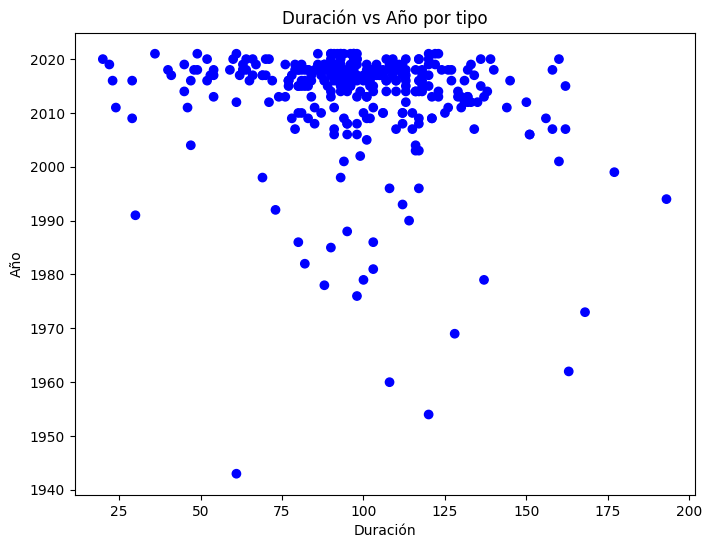

In [22]:
colors = df_clean["type"].map({"Movie":"blue", "TV Show":"orange"})

plt.figure(figsize=(8,6))
plt.scatter(df_clean["duration_num"], df_clean["release_year"], c=colors)

plt.xlabel("Duración")
plt.ylabel("Año")
plt.title("Duración vs Año por tipo")

plt.show()

**Análisis del gráfico**

El gráfico muestra que la duración de las películas se concentra en un rango aproximado entre 80 y 120 minutos.

No se observa una relación clara entre la duración y el año de lanzamiento, lo que sugiere que la duración de las películas se ha mantenido relativamente constante a lo largo del tiempo.

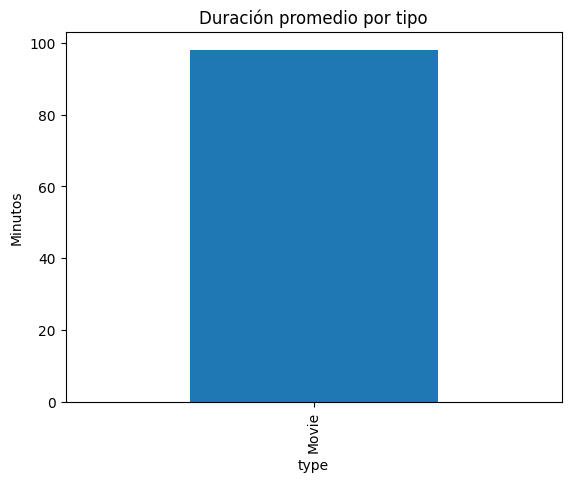

In [23]:
avg_duration = df_clean.groupby("type")["duration_num"].mean()

avg_duration.plot(kind="bar")

plt.title("Duración promedio por tipo")
plt.ylabel("Minutos")
plt.show()

El análisis muestra que la duración promedio de las películas es cercana a los 100 minutos, lo cual coincide con los estándares de la industria cinematográfica.

**Preparación para modelo**

In [24]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

le = LabelEncoder()
df_model["rating_encoded"] = le.fit_transform(df_model["rating"])
df_model["type_encoded"] = le.fit_transform(df_model["type"])

In [25]:
X = df_model[["duration_num", "release_year", "rating_encoded"]]
y = df_model["type_encoded"]

**Selección de variables**

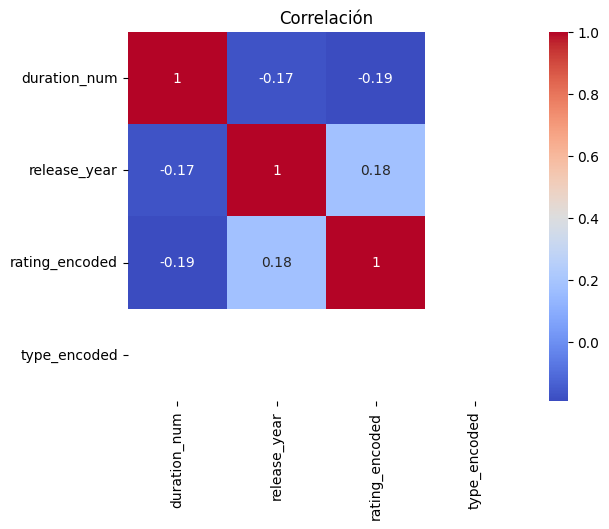

In [26]:
import seaborn as sns

corr = df_model[["duration_num","release_year","rating_encoded","type_encoded"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación")
plt.show()

Se utilizó una matriz de correlación para analizar la relación entre las variables.

Se observó que no existen correlaciones muy fuertes, lo que indica que las variables seleccionadas aportan información distinta al modelo.

**Modelo de clasificación**

Modelo de clasificación con el objetivo de identificar patrones en los datos a partir de las variables seleccionadas

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



**Evaluación**

El modelo presenta una buena precisión, lo que indica que puede clasificar correctamente el tipo de contenido en la mayoría de los casos.

**Valores faltantes**

Se identificaron valores faltantes en variables como "director", "cast" y "country".

Para este análisis, se eliminaron únicamente los registros con valores nulos en "duration" y "rating", ya que eran necesarios para el estudio.

**Conclusión**

El análisis permitió identificar que la duración de las películas en Netflix se mantiene en un rango relativamente estable, cercano a los 100 minutos.

No se encontró una relación significativa entre la duración y el año de lanzamiento, lo que sugiere que este aspecto no ha cambiado considerablemente con el tiempo.

Asimismo, la clasificación (rating) no parece influir de manera importante en la duración.

El modelo de machine learning mostró un desempeño aceptable, indicando que las variables utilizadas aportan información útil, aunque podrían mejorarse incorporando más variables.

Este proyecto demuestra cómo el análisis exploratorio y el uso de modelos permiten entender mejor los patrones en los datos de plataformas de streaming.